Loading Fashion MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Training data shape: (60000, 28, 28) (60,000 images, 28x28 pixels)
✅ Test data shape: (10000, 28, 28) (10,000 images, 28x28 pixels)


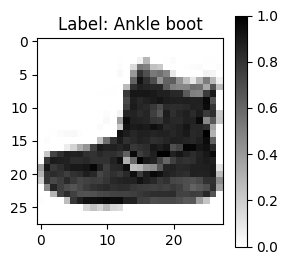

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("Loading Fashion MNIST dataset...")

# Load the dataset directly from Keras
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1 (Scaling)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class names for reference (10 categories of clothing)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"✅ Training data shape: {X_train.shape} (60,000 images, 28x28 pixels)")
print(f"✅ Test data shape: {X_test.shape} (10,000 images, 28x28 pixels)")

# Let's display the first image just to see what we are working with
plt.figure(figsize=(3,3))
plt.imshow(X_train[0], cmap=plt.cm.binary)
plt.title(f"Label: {class_names[y_train[0]]}")
plt.colorbar()
plt.show()

In [2]:
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from IPython.display import display

# 10 Different Hyperparameter Configurations for Fashion MNIST
experiments = [
    {'id': 1, 'layers': 1, 'nodes': [128], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline Model'},
    {'id': 2, 'layers': 1, 'nodes': [128], 'epochs': 30, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 3, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Deeper Network (2 Hidden)'},
    {'id': 4, 'layers': 2, 'nodes': [256, 128], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Wider & Deeper Network'},
    {'id': 5, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 20, 'batch': 64, 'lr': 0.001, 'note': 'Very Deep Network'},
    {'id': 6, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 128, 'lr': 0.001, 'note': 'Large Batch Size (Fast)'},
    {'id': 7, 'layers': 2, 'nodes': [128, 64], 'epochs': 15, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 8, 'layers': 2, 'nodes': [128, 64], 'epochs': 20, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate (Slow & Steady)'},
    {'id': 9, 'layers': 1, 'nodes': [32], 'epochs': 15, 'batch': 32, 'lr': 0.001, 'note': 'Small Sized Network'},
    {'id': 10, 'layers': 2, 'nodes': [512, 256], 'epochs': 30, 'batch': 64, 'lr': 0.001, 'note': 'Max Power (Heavy Model)'}
]

results = []
print(" Fashion MNIST Experiments started\n")

for exp in experiments:
    model = Sequential()
    
    # IMPORTANT: We must flatten the 28x28 image arrays into a 1D array (784 pixels)
    model.add(Flatten(input_shape=(28, 28)))
    
    # Add hidden layers dynamically
    for i in range(exp['layers']):
        model.add(Dense(exp['nodes'][i], activation='relu'))
    
    # Output layer: 10 neurons (for 10 classes) and 'softmax' activation
    model.add(Dense(10, activation='softmax'))
    
    # Compile the model
    optimizer = Adam(learning_rate=exp['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Train the model silently
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Evaluate with Test Data
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save results
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Layers': exp['layers'],
        'Nodes': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Batch Size': exp['batch'],
        'Learning Rate': exp['lr'],
        'Accuracy': round(accuracy, 4)
    })
    print(f"✅ Experiment {exp['id']} completed! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

# Save and Display
df_results = pd.DataFrame(results)
df_results.to_csv('Fashion_MNIST_Experiment_Results.csv', index=False, sep=';')
print("\n🎉 ALL EXPERIMENTS COMPLETED! Results saved.")
display(df_results)

 Fashion MNIST Experiments started



c:\Users\serza\Documents\GitHub\DEAI-Serzat\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ Experiment 1 completed! (Baseline Model) -> Accuracy: 87.92%
✅ Experiment 2 completed! (More Epochs) -> Accuracy: 88.84%
✅ Experiment 3 completed! (Deeper Network (2 Hidden)) -> Accuracy: 87.99%
✅ Experiment 4 completed! (Wider & Deeper Network) -> Accuracy: 88.80%
✅ Experiment 5 completed! (Very Deep Network) -> Accuracy: 89.27%
✅ Experiment 6 completed! (Large Batch Size (Fast)) -> Accuracy: 88.36%
✅ Experiment 7 completed! (High Learning Rate) -> Accuracy: 84.93%
✅ Experiment 8 completed! (Low Learning Rate (Slow & Steady)) -> Accuracy: 87.77%
✅ Experiment 9 completed! (Small Sized Network) -> Accuracy: 87.49%
✅ Experiment 10 completed! (Max Power (Heavy Model)) -> Accuracy: 89.29%

🎉 ALL EXPERIMENTS COMPLETED! Results saved.


,Experiment ID,Description,Layers,Nodes,Epochs,Batch Size,Learning Rate,Accuracy
0,1,Baseline Model,1,[128],10,32,0.0010,0.8792
1,2,More Epochs,1,[128],30,32,0.0010,0.8884
2,3,Deeper Network (2 Hidden),2,"[128, 64]",15,32,0.0010,0.8799
3,4,Wider & Deeper Network,2,"[256, 128]",15,32,0.0010,0.8880
4,5,Very Deep Network,3,"[256, 128, 64]",20,64,0.0010,0.8927
5,6,Large Batch Size (Fast),2,"[128, 64]",15,128,0.0010,0.8836
6,7,High Learning Rate,2,"[128, 64]",15,32,0.0100,0.8493
7,8,Low Learning Rate (Slow & Steady),2,"[128, 64]",20,32,0.0001,0.8777
8,9,Small Sized Network,1,[32],15,32,0.0010,0.8749
9,10,Max Power (Heavy Model),2,"[512, 256]",30,64,0.0010,0.8929


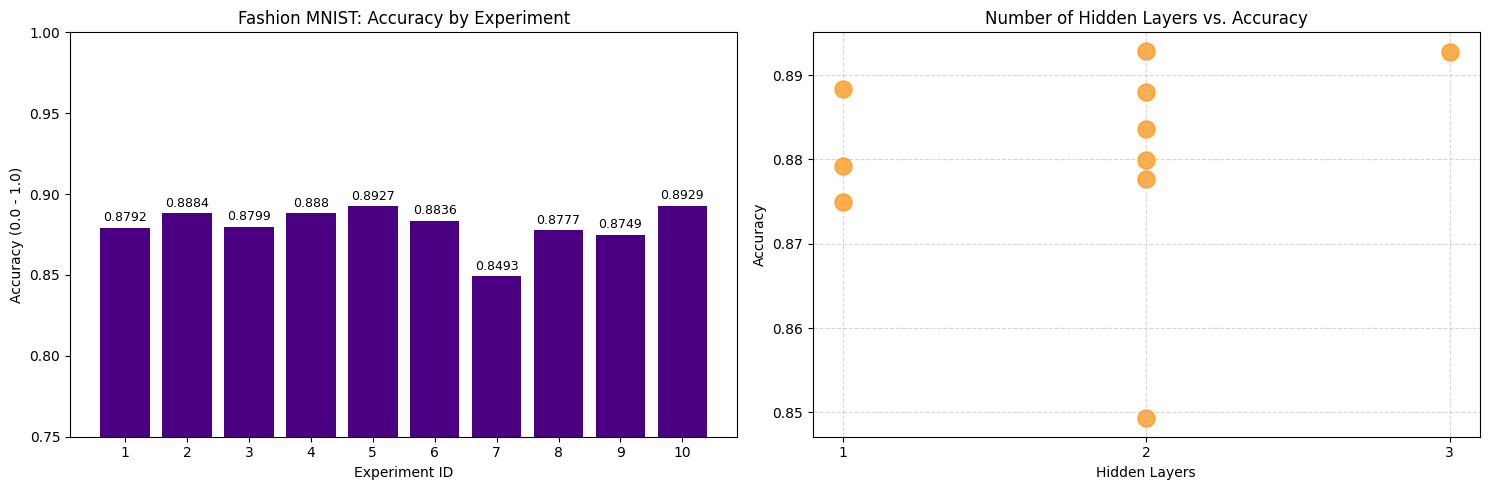

In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy Comparison
ax1.bar(df_results['Experiment ID'].astype(str), df_results['Accuracy'], color='indigo')
ax1.set_title('Fashion MNIST: Accuracy by Experiment')
ax1.set_xlabel('Experiment ID')
ax1.set_ylabel('Accuracy (0.0 - 1.0)')
ax1.set_ylim(0.75, 1.0) 
for i, v in enumerate(df_results['Accuracy']):
    ax1.text(i, v + 0.002, str(v), ha='center', va='bottom', fontsize=9)

# Plot 2: Layers vs Accuracy
ax2.scatter(df_results['Layers'], df_results['Accuracy'], color='darkorange', s=150, alpha=0.7)
ax2.set_title('Number of Hidden Layers vs. Accuracy')
ax2.set_xlabel('Hidden Layers')
ax2.set_ylabel('Accuracy')
ax2.set_xticks([1, 2, 3])
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()